# Modelos

## 1. Introducción y objetivos del modelado

Una vez finalizadas las etapas de análisis exploratorio y preprocesamiento, se dispone de un conjunto de datos preparado para desarrollar modelos de aprendizaje automático orientados a la predicción del precio de viviendas.

El objetivo principal del modelado es **predecir el precio de los inmuebles a partir de sus características estructurales, geográficas y de equipamiento**. Para ello, se utilizará `log_price` como variable objetivo, correspondiente a la transformación logarítmica de `price`, debido a la elevada asimetría que presenta la variable original.

A lo largo de este notebook se entrenarán y compararán diferentes modelos de regresión, buscando identificar aquel que proporcione un mejor equilibrio entre capacidad predictiva e interpretabilidad.

El proceso de modelado seguirá las siguientes etapas:

- Separación de las variables predictoras (`X`) y la variable objetivo (`y`).
- División de los datos en conjuntos de entrenamiento y prueba.
- Construcción de los pipelines de preprocesamiento necesarios para cada tipo de modelo.
- Entrenamiento y comparación de diferentes modelos de regresión.
- Selección del modelo con mejor rendimiento.
- Análisis de la importancia de las variables mediante **Permutation Importance**.
- Evaluación final del modelo y análisis de sus errores.

El conjunto de prueba se mantendrá separado durante el proceso de entrenamiento y selección de modelos, utilizándose únicamente en la evaluación final para obtener una estimación no sesgada de la capacidad predictiva del modelo seleccionado.

## 2. Carga y comprobación del dataset preprocesado

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/spanish_houses_preprocessed_final.csv")
df.head()


,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,energetic_certif,garden,house_type,lift,...,m2_real,price,reduced_mobility,room_num,storage_room,swimming_pool,terrace,population_prov,has_garage,log_price
0,0,0,2.0,0,0,segunda mano/buen estado,Desconocido,1,Casa o chalet independiente,0,...,1000,310000,0,4.0,0,0,1,328868,1,12.644328
1,0,0,2.0,0,0,segunda mano/buen estado,no indicado,0,Ático,1,...,86,139000,1,3.0,1,0,0,328868,0,11.842229
2,0,0,3.0,0,0,segunda mano/buen estado,no indicado,1,Casa de pueblo,0,...,3000,480000,0,4.0,1,0,1,328868,1,13.081541
3,0,1,1.0,1,1,segunda mano/buen estado,en trámite,1,Casa de pueblo,0,...,86,150000,0,4.0,1,0,1,328868,0,11.918391
4,0,0,1.0,0,0,segunda mano/buen estado,no indicado,1,Piso,1,...,76,90000,0,2.0,1,1,1,328868,1,11.407565


In [2]:
pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "n_unique": df.nunique().values
})

,variable,tipo,n_unique
0,air_conditioner,int64,2
1,balcony,int64,2
2,bath_num,float64,26
3,built_in_wardrobe,int64,2
4,chimney,int64,2
5,condition,object,4
6,energetic_certif,object,4
7,garden,int64,2
8,house_type,object,18
9,lift,int64,2


Se carga el conjunto de datos resultante del preprocesamiento realizado en el notebook `04_final_preprocessing`. En esta etapa no se realizan nuevas transformaciones sobre los datos, sino que se comprueba que el archivo exportado mantiene las condiciones definidas al finalizar el preprocesamiento.

El dataset final contiene **88.964 registros y 21 variables**, sin valores ausentes ni registros duplicados.

Además, se verifica que se mantienen las variables necesarias para el modelado, incluyendo `price` y `log_price`, mientras que las variables descartadas durante el preprocesamiento, como `house_id`, `ad_last_update` y `obtention_date`, ya no forman parte del conjunto de datos.

Una vez realizadas estas comprobaciones, el dataset se considera preparado para comenzar la construcción del conjunto de variables predictoras y la variable objetivo.

## 3. Separación de variables predictoras y objetivo

In [3]:
target = "log_price"

# Dejamos price y log price fuera de las variables predictoras
X = df.drop(columns=["price", "log_price"])
y = df[target]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (88964, 19)
Dimensiones de y: (88964,)


In [4]:
# Variables predictoras
X.columns.tolist()

['air_conditioner',
 'balcony',
 'bath_num',
 'built_in_wardrobe',
 'chimney',
 'condition',
 'energetic_certif',
 'garden',
 'house_type',
 'lift',
 'loc_zone',
 'm2_real',
 'reduced_mobility',
 'room_num',
 'storage_room',
 'swimming_pool',
 'terrace',
 'population_prov',
 'has_garage']

La variable objetivo seleccionada para el modelado es `log_price`, correspondiente a la transformación logarítmica de `price` realizada durante el preprocesamiento.

Las variables predictoras se almacenan en `X`, mientras que la variable objetivo se almacena en `y`.

Se excluyen tanto `log_price` como `price` de las variables predictoras. `log_price` se excluye por ser la propia variable objetivo, mientras que `price` se excluye porque contiene exactamente la misma información que `log_price` en su escala original. Incluir cualquiera de estas variables como predictor provocaría una situación de **data leakage**.

De este modo, el modelo utilizará únicamente las características descriptivas del inmueble y su localización para realizar las predicciones.

## 4. Separación train/test

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [6]:
pd.DataFrame({
    "conjunto": ["Train", "Test"],
    "n_registros": [len(X_train), len(X_test)],
    "porcentaje": [
        len(X_train) / len(X) * 100,
        len(X_test) / len(X) * 100
    ]
})

,conjunto,n_registros,porcentaje
0,Train,71171,79.999775
1,Test,17793,20.000225


Antes de realizar cualquier transformación que requiera aprender parámetros a partir de los datos, se divide el conjunto de datos en un conjunto de entrenamiento y otro de prueba.

Se utiliza una división **80/20**, reservando el 80 % de las observaciones para el entrenamiento de los modelos y el 20 % restante para su evaluación final. Se fija `random_state=42` para garantizar la reproducibilidad de los resultados.

Esta separación se realiza antes del preprocesamiento específico de los modelos para evitar **data leakage**. De esta forma, cualquier parámetro aprendido durante el escalado de variables numéricas o la codificación de variables categóricas se obtiene exclusivamente a partir del conjunto de entrenamiento.

El conjunto de prueba se mantiene aislado durante el entrenamiento y la selección de modelos y se utilizará posteriormente para obtener una estimación de la capacidad de generalización del modelo seleccionado.

## 5. Preprocesamiento para los modelos

En esta sección se preparan las variables predictoras para que puedan ser utilizadas correctamente por los modelos seleccionados. Se van a realizar 3 modelos:

1. Baseline
2. Regresión Lineal Múltiple
3. Random Forest Regressor

En el modelo baseline, no se necesitará ningún tratamiento, pero para los otros 2 modelos, las variables necesitarán un tratamiento distinto.

Las variables categóricas deberán transformarse mediantee One-Hot Encoding, mientras que las variables numéricas se mantendrán en su escala original para Random Forest y se estandarizarán mediante StandardScaler para la regresión lineal.

Para evitar diferencias en el tratamiento de los datos entre entrenamiento y test, estas transformaciones se integrarán posteriormente en un Pipeline.

### 5.1. Identificación de variables numéricas y categóricas

In [7]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Variables categóricas:")
print(categorical_cols)

print("\nVariables numéricas:")
print(numerical_cols)

Variables categóricas:
['condition', 'energetic_certif', 'house_type', 'loc_zone']

Variables numéricas:
['air_conditioner', 'balcony', 'bath_num', 'built_in_wardrobe', 'chimney', 'garden', 'lift', 'm2_real', 'reduced_mobility', 'room_num', 'storage_room', 'swimming_pool', 'terrace', 'population_prov', 'has_garage']


### 5.2. Preprocesamiento para la regresión lineal

La regresión lineal múltiple necesita que todas las variables predictoras estén representadas numéricamente. En nuestro dataset, tenemos 2 tipos de variables: categóricas y numéricas. Por lo tanto, debemos convertir las categóricas a una representación numérica.

Por otra parte, se estadarizarán las variables numéricas mediante StandardScaler. 

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [9]:
# Crear el ColumnTransformer

preprocessor_linear = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols)
])

### 5.3. Preprocesamiento para Random Forest

La idea es parecido al preprocesamiento de la regresión lineal, pero no será necesario escalar las variables numéricas, ya que Random Forest funciona mediante reglas y no nos aportaría ningún beneficio.

In [10]:
# En este caso se usa el parámetro "passthrough" que significa, deja estas columnas como están.
preprocessor_rf = ColumnTransformer(transformers=[
    ("num", "passthrough", numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

### 5.4. Creación de los pipelines

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Pipeline para regresión lineal
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor_linear),
    ("model", LinearRegression())
])

# Pipeline para random forest
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestRegressor(
        n_estimators=200,   # Número de árboles
        random_state=42,
        n_jobs=-1           # Usar todos los núcleos del procesador
    ))
])

Al usar `ColumnTransformer` definimos la preparación de los datos; luego, el `Pipeline` conecta el preprocesamiento con el modelo y garantiza que las transformaciones se aprendan únicamente a partir de ´X_train´.

## 6. Modelos candidatos

En este apartado se entrenarán y evaluarán tres alternativas con distintos modelos de complejidad:

- Modelo baseline: establece la referencia mínima de rendimiento.
- Regresión lineal múltiple: modelo lineal.
- Random Forest Regressor: permite capturar relaciones no lineales e interacciones entre variables.

### 6.1. Modelo baseline

Este modelo servirá como referencia para responder a una pregunta: ¿Nuestros modelos realmente están aprendiendo algo útil? 

Se busca que este modelo sirva de referencia simple y que sea difícil de superar por casualidad.

En nuestro caso, dado que se predice `log_price`, se utilizará como baseline la mediana de `y_train`. Es decir, se predice siempre el mismo valor. Podríamos usar la media, pero seguiremos con la mediana, aunque con `log_price` se haya solucionado el problema de asimetría que teníamos con `price`.

In [12]:
# Calculamos el valor de la predicción usando solamente los datos de entrenamiento --> y_train
baseline_value = y_train.median()

In [13]:
# Predicciones del baseline sobre el conjunto de test
y_pred_baseline = np.full(len(y_test), baseline_value)

print(f"Predicción baseline: {baseline_value:.4f}")

Predicción baseline: 12.2830


### 6.2. Regresión lineal múltiple

La Regresión Lineal Múltiple modela la relación entre la variable objetivo y el conjunto de variables predictoras. A diferencia del baseline, que realiza siempre la misma predicción, este modelo utiliza la información disponible de las características de cada vivienda.

En este apartado gacemos el entrenamiento y generamos las predicciones.

In [14]:
# Entrenar el pipeline

linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['air_conditioner', 'balcony',
                                                   'bath_num',
                                                   'built_in_wardrobe',
                                                   'chimney', 'garden', 'lift',
                                                   'm2_real',
                                                   'reduced_mobility',
                                                   'room_num', 'storage_room',
                                                   'swimming_pool', 'terrace',
                                                   'population_prov',
                                                   'has_garage']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['condition',
                                                   'energetic_certif',
                                                   'house_type',
                                                   'loc_zone'])])),
                ('model', LinearRegression())])

In [15]:
# Generamos las predicciones sobre el conjunto de test
y_pred_linear = linear_pipeline.predict(X_test)

### 6.3. Random Forest

Se realiza el mismo procedimiento que con la regresión lineal, entrenamiento y generación de predicciones.

In [16]:
# Entrenar el pipeline
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['air_conditioner', 'balcony',
                                                   'bath_num',
                                                   'built_in_wardrobe',
                                                   'chimney', 'garden', 'lift',
                                                   'm2_real',
                                                   'reduced_mobility',
                                                   'room_num', 'storage_room',
                                                   'swimming_pool', 'terrace',
                                                   'population_prov',
                                                   'has_garage']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['condition',
                                                   'energetic_certif',
                                                   'house_type',
                                                   'loc_zone'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [17]:
# Generamos las predicciones sobre el conjunto de test
y_pred_rf = rf_pipeline.predict(X_test)

## 7. Evaluación y comparación de los modelos

En este apartado se evalúa el rendimiento de los modelos desarrollados utilizando el mismo conjunto de test y las mismas métricas de evaluación. Esto nos permite determinar que modelo ofrece un mejor comportamiento predictivo.

Como la variable objetivo utilizada durante el modelado es `log_price`, las métricas se calcularán inicialmente sobre esta escala. Posteriormente se podrá realizar la interpretación adicional de las predicciones en la escala original de precios.

### 7.1. Definición de las métricas

Se van a utilizar las siguientes métricas:

- MSE - Mean Squared Error: Calcula el promedio de los errores al cuadrado. Penaliza especialmente los errores grandes.
- MAE - Mean Absolute Error: Calcula el error absoluto medio. Representa el tamaño medio del error, por lo que es muy intuitiva. En nuestro caso inicialmente expresado en la escala de `log_price`.
- RMSE - Root Mean Squared Error: Raíz cuadrada del MSE. Tiene la ventaja de estar en la misma escala que la variable objetivo.
- $R^2$ - Coeficiente de determinación: Indica que proporción de la variabilidad de `log_price` es explicada por el modelo. Cuanto más cercano a 1 mejor.

Se crea la función evaluar_modelo que nos servirá para los 3 modelos.

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [19]:
def evaluar_modelo(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R²": r2_score(y_true, y_pred)
    }

### 7.2. Evaluación del modelo baseline

In [20]:
resultados_baseline = evaluar_modelo(y_test, y_pred_baseline)
pd.DataFrame(resultados_baseline, index=["Baseline"])

,MSE,MAE,RMSE,R²
Baseline,0.928343,0.742103,0.963505,-0.004643


### 7.3. Evaluación de la regresión lineal

In [21]:
resultados_linear = evaluar_modelo(y_test, y_pred_linear)
pd.DataFrame(resultados_linear, index=["Regresión Lineal"])

,MSE,MAE,RMSE,R²
Regresión Lineal,0.238418,0.355907,0.488281,0.741986


### 7.4. Evaluación de Random Forest

In [22]:
resultados_rf = evaluar_modelo(y_test, y_pred_rf)
pd.DataFrame(resultados_rf, index=["Random Forest"])

,MSE,MAE,RMSE,R²
Random Forest,0.153774,0.286378,0.392141,0.833587


### 7.5. Comparación de resultados

In [23]:
resultados = pd.DataFrame({
    "Baseline": evaluar_modelo(y_test, y_pred_baseline),
    "Regresión lineal": evaluar_modelo(y_test, y_pred_linear),
    "Random Forest": evaluar_modelo(y_test, y_pred_rf)
}).T

resultados

,MSE,MAE,RMSE,R²
Baseline,0.928343,0.742103,0.963505,-0.004643
Regresión lineal,0.238418,0.355907,0.488281,0.741986
Random Forest,0.153774,0.286378,0.392141,0.833587


**Conclusión:** Las métricas utilizadas permiten evaluar el rendimiento de los modelos desde diferentes perspectivas. El **MSE** mide el error cuadrático medio y penaliza especialmente los errores grandes. En nuestro caso, el Random Forest obtiene un MSE de **0,1538**, frente a **0,2384** de la regresión lineal y **0,9283** del baseline, por lo que presenta los menores errores cuadráticos.

El **MAE** mide el error absoluto medio. El Random Forest obtiene un valor de **0,2864**, lo que indica que, en promedio, el error absoluto de las predicciones es de aproximadamente **0,29 unidades de `log_price`**. La regresión lineal obtiene **0,3559**, mientras que el baseline alcanza **0,7421**.

El **RMSE** también mide el tamaño de los errores, pero penaliza más los errores grandes. Random Forest obtiene **0,3921**, frente a **0,4883** de la regresión lineal y **0,9635** del baseline. Por tanto, el Random Forest presenta también el menor nivel de error según esta métrica.

Por último, el **R²** indica qué proporción de la variabilidad de `log_price` consigue explicar el modelo. La regresión lineal obtiene un **R² = 0,7420**, por lo que explica aproximadamente el **74,2 %** de la variabilidad de la variable objetivo. Random Forest alcanza un **R² = 0,8336**, explicando aproximadamente el **83,4 %**, mientras que el baseline obtiene un valor negativo (**−0,0046**), lo que indica que su capacidad predictiva es prácticamente nula.

En conjunto, **Random Forest obtiene el mejor resultado en las cuatro métricas**, por lo que se establece como el principal candidato a modelo final. No obstante, estas métricas están calculadas sobre `log_price` y no directamente sobre euros; la interpretación de los errores en la escala original de `price` se realizará posteriormente.

*Las métricas se han calculado sobre `log_price`, por lo que sus valores no están expresados directamente en euros. La evaluación en la escala original de `price` se realizará posteriormente.*

## 8. Análisis de los modelos

Una vez evaluados y comparados los modelos, se procede a analizar con mayor detalle su comportamiento y capacidad predictiva. En primer lugar, se estudian los coeficientes obtenidos por el modelo de regresión lineal múltiple. Posteriormente, se selecciona el modelo con mejor rendimiento y se analizan sus predicciones en la escala original de precios, así como sus errores y la importancia de las variables predictoras. Para el modelo final elegido, se utilizarán técnicas de interpretación específicas, como Permutation Importance.

### 8.1. Análisis de coeficientes de la regresión lineal

La regresión lineal múltiple permite analizar la relación entre las variables predictoras y la variable objetivo mediante los coeficientes estimados para el modelo. Dado que el modelo utiliza `log_price` como variable objetivo y las variables numéricas han sido estandarizadas, los coeficientes permiten esetudiar la dirección de la relación y comparar la magnitud de las asociaciones entre las variables.

In [24]:
# Obtenemos columnas. Han cambiado por el One Hot-Encoding
nombres_variables_linear = linear_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [25]:
# Obtener los coeficientes
coeficientes_linear = linear_pipeline.named_steps["model"].coef_

# Comprobamos que coinciden el número de variables con el de coeficientes
len(nombres_variables_linear), len(coeficientes_linear)

(130, 130)

In [26]:
# Tabla de coeficientes
df_coeficientes = pd.DataFrame({
    "variable": nombres_variables_linear,
    "coeficiente": coeficientes_linear
})

df_coeficientes.head()

,variable,coeficiente
0,num__air_conditioner,0.047274
1,num__balcony,-0.003172
2,num__bath_num,0.283457
3,num__built_in_wardrobe,0.032083
4,num__chimney,0.013610


In [27]:
df_coeficientes["abs_coeficiente"] = (
    df_coeficientes["coeficiente"].abs()
)

df_coeficientes_ordenados = (
    df_coeficientes
    .sort_values("abs_coeficiente", ascending=False)
)

df_coeficientes_ordenados.head(20)

,variable,coeficiente,abs_coeficiente
53,cat__loc_zone_Balears (Illes),2.315395,2.315395
73,"cat__loc_zone_Ibiza, Balears (Illes)",1.817534,1.817534
65,"cat__loc_zone_Donostialdea, Guipúzcoa",1.644338,1.644338
83,"cat__loc_zone_Mallorca, Balears (Illes)",1.399757,1.399757
51,"cat__loc_zone_Bajo Bidasoa, Guipúzcoa",1.377119,1.377119
72,"cat__loc_zone_Gran Bilbao, Vizcaya",1.307294,1.307294
110,"cat__loc_zone_Uribe-Butroe, Vizcaya",1.268300,1.268300
111,"cat__loc_zone_Urola Kosta, Guipúzcoa",1.259930,1.259930
118,cat__loc_zone_Álava,1.192723,1.192723
85,"cat__loc_zone_Menorca, Balears (Illes)",1.139159,1.139159


In [28]:
onehot = linear_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
dict(zip(categorical_cols, onehot.categories_))

{'condition': array(['Desconocido', 'promoción de obra nueva',
        'segunda mano/buen estado', 'segunda mano/para reformar'],
       dtype=object),
 'energetic_certif': array(['Desconocido', 'en trámite', 'inmueble exento', 'no indicado'],
       dtype=object),
 'house_type': array(['Casa de pueblo', 'Casa o chalet', 'Casa o chalet independiente',
        'Casa rural', 'Casa terrera', 'Caserón', 'Castillo',
        'Chalet adosado', 'Chalet pareado', 'Cortijo', 'Dúplex', 'Estudio',
        'Finca rústica', 'Masía', 'Palacio', 'Piso', 'Torre', 'Ático'],
       dtype=object),
 'loc_zone': array(['A Barcala, A Coruña', 'A Coruña', 'Alfoz de Toro, Zamora',
        'Aliste, Zamora', 'Aljarafe, Sevilla', 'Almazán, Soria',
        'Alt Empordà, Girona', 'Alt Penedès, Barcelona',
        'Alt Vinalopó, Alicante', 'Alto Deba, Guipúzcoa',
        'Arratia-Nervión, Vizcaya', 'Arzúa, A Coruña', 'Ayala, Álava',
        'Añana, Álava', 'Bajo Bidasoa, Guipúzcoa', 'Bajo Deba, Guipúzcoa',
        '

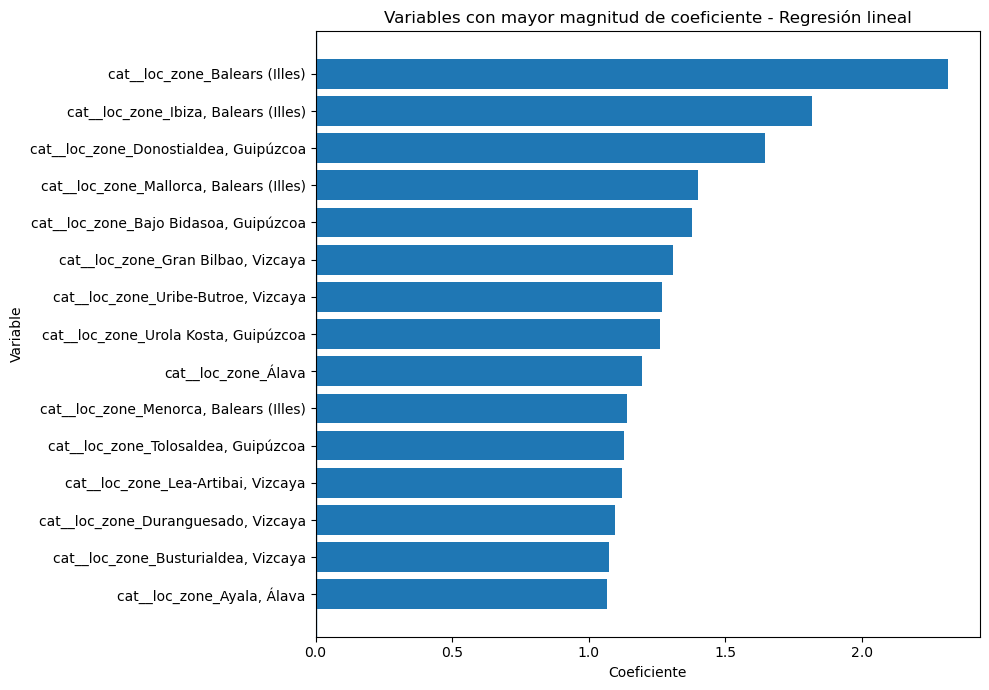

In [29]:
# Gráfico con los coeficientes de mayor magnitud

import matplotlib.pyplot as plt

top_coef = (
    df_coeficientes
    .sort_values("abs_coeficiente", ascending=False)
    .head(15)
    .sort_values("coeficiente")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_coef["variable"],
    top_coef["coeficiente"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.title("Variables con mayor magnitud de coeficiente - Regresión lineal")

plt.tight_layout()
plt.show()

**Conclusión:** Los coeficientes de la regresión lineal muestran que la **localización (`loc_zone`) presenta una fuerte relación con `log_price`**, ya que las categorías con mayor magnitud de coeficiente corresponden principalmente a distintas zonas geográficas. Esto pone de manifiesto la relevancia de la ubicación en la determinación del precio de la vivienda. No obstante, dado que la regresión lineal presenta un rendimiento inferior al Random Forest, este análisis se considera **complementario**, y la interpretación principal del modelo se realizará sobre Random Forest mediante técnicas de importancia de variables.


### 8.2. Selección del modelo final

En este apartado se selecciona el modelo que se utilizará como modelo final para la predicción del precio de viviendas. La selección se realiza a partir de los resultados del apartado 7, comparando el rendimiento del baseline, la regresión lineal múltiple y Random Forest sobre el conjunto test.

In [30]:
modelo_final = rf_pipeline

print("Modelo final seleccionado: Random Forest")

Modelo final seleccionado: Random Forest


In [31]:
pd.DataFrame(resultados_rf, index=["Random Forest"])

,MSE,MAE,RMSE,R²
Random Forest,0.153774,0.286378,0.392141,0.833587


**Selección del modelo final**

A partir de la comparación realizada en el apartado 7, se selecciona **Random Forest como modelo final**, al obtener el mejor rendimiento en el conjunto de test. El modelo alcanza un **R² de 0,8336**, frente a 0,7420 de la regresión lineal, y presenta también los valores más bajos de MSE, MAE y RMSE.

Por tanto, Random Forest será el modelo utilizado en los siguientes apartados para analizar las predicciones en la escala original de `price`, estudiar sus errores y analizar la importancia de las variables mediante **Permutation Importance**.

### 8.3. Predicciones del Modelo Final en Euros

El modelo final, Random Forest, ha sido entrenado utilizando `log_price` como variable objetivo. Para facilitar la interpretación de sus resultados, en este apartado se transforman las predicciones obtenidas a la escala original de `price`, expresada en euros. De esta forma, las predicciones y los errores del modelo pueden interpretarse directamente en términos del precio de la vivienda.

In [32]:
# Pasamos los precios predichos a euros
y_pred_price = np.exp(y_pred_rf) # precio predicho en euros

In [33]:
# Transformamos también y_test para poder compararlo
y_test_price = np.exp(y_test) # precio real el euros

In [34]:
# Visualizamos algunas predicciones
pd.DataFrame({
    "precio_real": y_test_price.round(0),
    "precio_predicho": y_pred_price.round(0)
}).head(10)

,precio_real,precio_predicho
27401,518000.0,901707.0
14267,1760000.0,1566303.0
66346,350000.0,370941.0
30526,239000.0,310684.0
80867,190000.0,145053.0
58962,149000.0,187527.0
64765,105000.0,192991.0
22802,1590000.0,361726.0
46826,85000.0,114729.0
8589,280000.0,471343.0


In [35]:
resultados_modelo_final_euros = evaluar_modelo(y_test_price, y_pred_price)
pd.DataFrame({
    "MAE (€)": [resultados_modelo_final_euros["MAE"]],
    "RMSE (€)": [resultados_modelo_final_euros["RMSE"]],
    "R²": [resultados_modelo_final_euros["R²"]]
}, index=["Modelo Final"])

,MAE (€),RMSE (€),R²
Modelo Final,128730.940086,393133.27057,0.613799


**Conclusión:** Al transformar las predicciones a la escala original, el modelo presenta un **MAE de 128.730,94 €**, por lo que el error absoluto medio de las predicciones es de aproximadamente 128.731 €. El **RMSE de 393.133,27 €**, considerablemente superior al MAE, indica la presencia de algunos errores de gran magnitud. Por su parte, el **R² de 0,6138** muestra que el modelo explica aproximadamente el 61,4 % de la variabilidad observada en los precios en euros. Estos resultados permiten interpretar el rendimiento del modelo desde una perspectiva más próxima al problema real de predicción del precio de las viviendas.

Observaciones:

0,8336 → R² calculado sobre log_price.
0,6138 → R² calculado después de volver a price (€).

Al aplicar np.exp() dejamos de estar en una transformación lineal, por lo que las métricas no tienen por qué conservarse. Sin embargo, nos significa que el modelo haya empeorado, sino que el rendimiento se está evaluando ahora en una escala diferente.

### 8.4. Precio Real vs Precio Predicho

Para evaluar visualmente el comportamiento del modelo final, se comparan los precios reales del conjunto de test con los precios predichos por Random Forest. La línea diagonal representa la situación ideal, en la que el precio predicho coincide exactamente con el precio real. Cuanto más próximos se encuentren los puntos a esta línea, menor será el error de predicción.

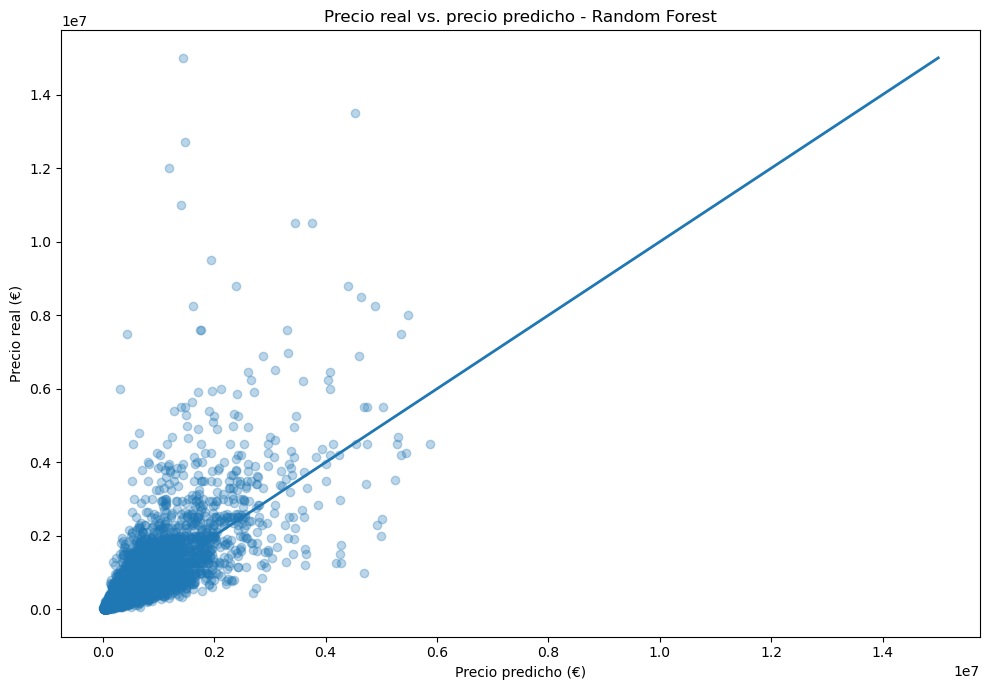

In [36]:
plt.figure(figsize=(10, 7))

plt.scatter(
    y_pred_price,
    y_test_price,
    alpha=0.3
)

min_val = min(
    y_test_price.min(),
    y_pred_price.min()
)

max_val = max(
    y_test_price.max(),
    y_pred_price.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linewidth=2
)

plt.xlabel("Precio predicho (€)")
plt.ylabel("Precio real (€)")
plt.title("Precio real vs. precio predicho - Random Forest")

plt.tight_layout()
plt.show()

**Conclusión:** El gráfico muestra una relación positiva entre el precio real y el precio predicho, ya que la mayor concentración de observaciones sigue la dirección de la línea de predicción perfecta. Sin embargo, se observa una dispersión considerable respecto a dicha línea, especialmente en las viviendas de precios más elevados. Además, aparecen algunos valores extremos cuyo precio real se encuentra muy por encima del precio predicho. Esto indica que, aunque el modelo captura de forma razonable la relación general entre las características de las viviendas y su precio, **presenta mayores dificultades para predecir correctamente los inmuebles de precio muy elevado**. Estos resultados justifican analizar con mayor detalle los errores de predicción en el siguiente apartado.

### 8.5. Análisis de errores

Para profundizar en el comportamiento del modelo final, se analizan los errores cometidos sobre el conjunto de test. Para ello, se compara el precio real de cada vivienda con su precio predicho y se estudia tanto la magnitud como la dirección de los errores. Este análisis permite identificar posibles patrones y detectar observaciones en las que el modelo presenta mayores dificultades.

In [37]:
# Calculamos el error como precio real - precio predicho
# Error positivo -> subestima el precio. 
# Error negativo -> sobreestima el precio.

errores = pd.DataFrame({
    "precio_real": y_test_price.round(0),
    "precio_predicho": y_pred_price.round(0)
})

errores["error"] = (errores["precio_real"] - errores["precio_predicho"]).round(0)
errores["error_absoluto"] = (errores["error"].abs()).round(0)

errores.head(10)

,precio_real,precio_predicho,error,error_absoluto
27401,518000.0,901707.0,-383707.0,383707.0
14267,1760000.0,1566303.0,193697.0,193697.0
66346,350000.0,370941.0,-20941.0,20941.0
30526,239000.0,310684.0,-71684.0,71684.0
80867,190000.0,145053.0,44947.0,44947.0
58962,149000.0,187527.0,-38527.0,38527.0
64765,105000.0,192991.0,-87991.0,87991.0
22802,1590000.0,361726.0,1228274.0,1228274.0
46826,85000.0,114729.0,-29729.0,29729.0
8589,280000.0,471343.0,-191343.0,191343.0


In [38]:
errores[["error", "error_absoluto"]].describe().round(0)

,error,error_absoluto
count,17793.0,17793.0
mean,34807.0,128731.0
std,391600.0,371470.0
min,-3693864.0,0.0
25%,-40214.0,16170.0
50%,-1290.0,42133.0
75%,44613.0,105701.0
max,13565566.0,13565566.0


In [39]:
# Visualizamos las viviendas con los errores más grandes

errores_mayores = (
    errores
    .sort_values("error_absoluto", ascending=False)
    .head(10)
)

errores_mayores

,precio_real,precio_predicho,error,error_absoluto
76948,15000000.0,1434434.0,13565566.0,13565566.0
33070,12700000.0,1479624.0,11220376.0,11220376.0
33829,12000000.0,1194016.0,10805984.0,10805984.0
26224,11000000.0,1405978.0,9594022.0,9594022.0
22780,13500000.0,4521765.0,8978235.0,8978235.0
13970,9500000.0,1946377.0,7553623.0,7553623.0
26124,7500000.0,429937.0,7070063.0,7070063.0
10602,10500000.0,3447732.0,7052268.0,7052268.0
10409,10500000.0,3759094.0,6740906.0,6740906.0
20747,8250000.0,1613813.0,6636187.0,6636187.0


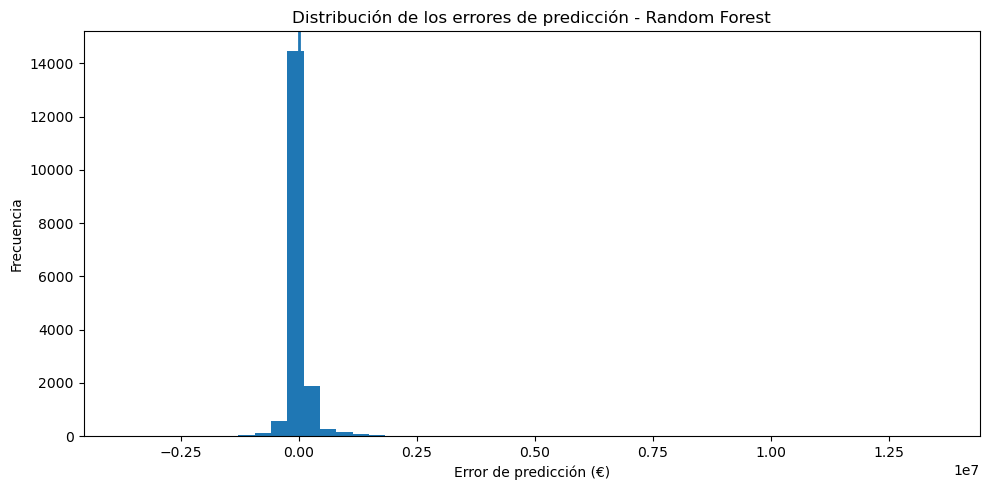

In [40]:
# Distribución de los errores

plt.figure(figsize=(10, 5))

plt.hist(
    errores["error"],
    bins=50
)

plt.axvline(
    0,
    linewidth=2
)

plt.xlabel("Error de predicción (€)")
plt.ylabel("Frecuencia")
plt.title("Distribución de los errores de predicción - Random Forest")

plt.tight_layout()
plt.show()

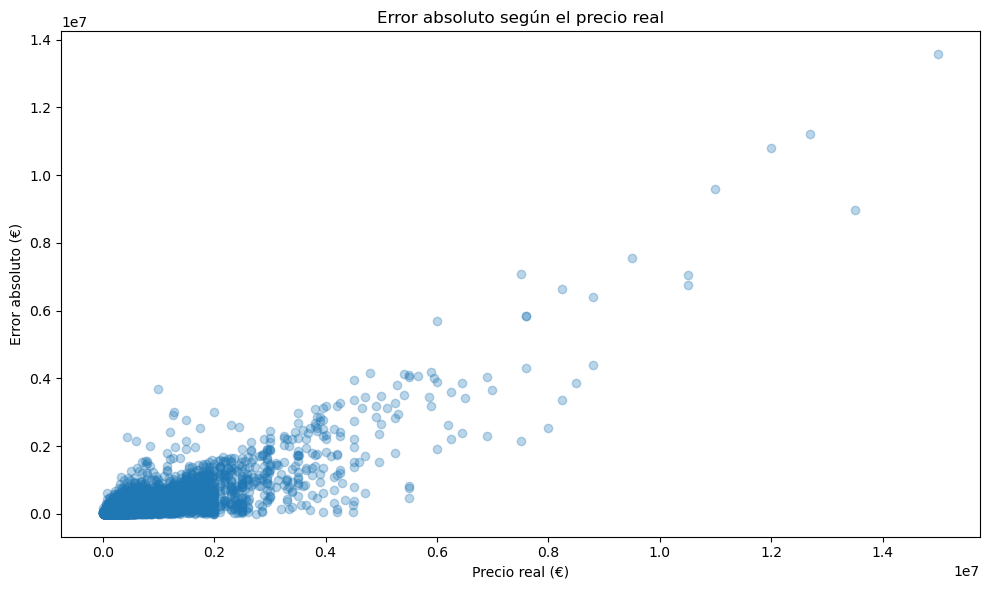

In [41]:
# Error frente al precio real

plt.figure(figsize=(10, 6))

plt.scatter(
    errores["precio_real"],
    errores["error_absoluto"],
    alpha=0.3
)

plt.xlabel("Precio real (€)")
plt.ylabel("Error absoluto (€)")
plt.title("Error absoluto según el precio real")

plt.tight_layout()
plt.show()

**Conclusión:** El análisis de los errores muestra que la mayoría de las predicciones presentan errores moderados, con una mediana del error absoluto de **42.133 €** y un 75 % de las observaciones con errores inferiores a **105.701 €**. Sin embargo, se identifican algunos errores de magnitud excepcionalmente elevada, lo que explica la diferencia entre el **MAE de 128.731 €** y el **RMSE de 393.133 €**. Estos errores se concentran principalmente en viviendas de precio muy elevado, que el modelo tiende a subestimar considerablemente. La relación observada entre el precio real y el error absoluto indica, por tanto, que **la precisión del modelo disminuye a medida que aumenta el precio de la vivienda**, especialmente en los valores extremos de la distribución.

### 8.6. Permutation Importance

Para analizar la importancia de las variables utilizadas por el modelo final, se emplea la técnica **Permutation Importance**. Este método mide cuánto empeora el rendimiento del modelo cuando los valores de una variable se permutan aleatoriamente, rompiendo su relación con la variable objetivo. Una mayor disminución del rendimiento indica que dicha variable aporta más información al modelo.

El análisis se realiza sobre el conjunto de test, utilizando el modelo final ya entrenado, con el objetivo de evaluar la importancia de las variables sobre datos no utilizados durante el entrenamiento.

In [42]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(modelo_final, X_test, y_test,scoring="r2", n_repeats=10, random_state=42)

In [43]:
df_importancia = pd.DataFrame({
    "variable": X_test.columns,
    "importancia": perm_importance.importances_mean
})

df_importancia = (
    df_importancia
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

df_importancia

,variable,importancia
0,population_prov,0.550259
1,m2_real,0.327769
2,bath_num,0.203405
3,loc_zone,0.120199
4,lift,0.049341
5,house_type,0.032354
6,room_num,0.019024
7,condition,0.016507
8,swimming_pool,0.009330
9,air_conditioner,0.006696


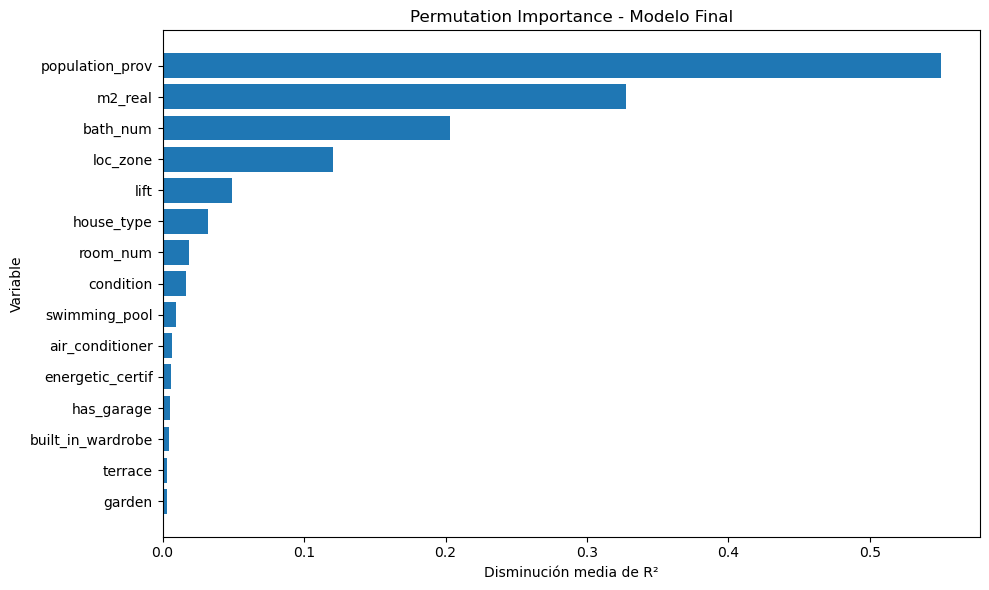

In [44]:
top_importance = df_importancia.head(15).sort_values(
    "importancia"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_importance["variable"],
    top_importance["importancia"]
)

plt.xlabel("Disminución media de R²")
plt.ylabel("Variable")
plt.title("Permutation Importance - Modelo Final")

plt.tight_layout()
plt.show()


**Conclusión:** El análisis mediante Permutation Importance muestra que la importancia de las variables no está distribuida de forma uniforme. **`population_prov` es la variable más relevante**, con una disminución media del R² de **0,5503** al permutarla, seguida de **`m2_real` (0,3278)** y **`bath_num` (0,2034)**. También destaca la variable **`loc_zone` (0,1202)**, lo que confirma la relevancia de la localización en la predicción del precio. El resto de variables presentan una importancia considerablemente menor. En conjunto, los resultados indican que el modelo se apoya principalmente en **la ubicación y las características estructurales de la vivienda**, mientras que características adicionales como terraza, jardín, piscina o garaje tienen una contribución más reducida.

Es destacable que este resultado difiere parcialmente del análisis de coeficientes realizado para la regresión lineal, donde las categorías de `loc_zone` presentaban algunos de los mayores coeficientes absolutos. Esta diferencia no supone una contradicción, ya que los coeficientes miden el efecto de cada categoría dentro de la regresión lineal, mientras que Permutation Importance mide la pérdida de rendimiento del Random Forest al eliminar la información de una variable. Por tanto, **los resultados deben interpretarse en el contexto de cada modelo y no son directamente comparables en magnitud**.

## 9. Conclusiones del modelado

La comparación realizada muestra que **Random Forest** es el modelo que ofrece el mejor rendimiento predictivo entre las alternativas estudiadas, por lo que se selecciona como modelo final. Al transformar sus predicciones a la escala original, obtiene un **MAE de 128.730,94 €**, un **RMSE de 393.133,27 €** y un **R² de 0,6138**. Esto indica que, aunque el modelo consigue explicar una parte importante de la variabilidad de los precios, mantiene errores elevados en determinados inmuebles, especialmente en viviendas de precios excepcionalmente altos.

El análisis mediante **Permutation Importance** muestra que `population_prov` y `m2_real` son los predictores con mayor influencia sobre el rendimiento del modelo, seguidos por `bath_num` y `loc_zone`. Estos resultados permiten complementar la evaluación predictiva con una interpretación de qué variables contribuyen en mayor medida a las predicciones.
